In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = '/Users/pirey/Dropbox/imc-prosperity-4/ROUND_3'
PRODUCT  = 'HYDROGEL_PACK'
POS_LIMIT = 100

In [19]:
# ── Load and filter price data ──────────────────────────────────────────────
price_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'{DATA_DIR}/prices_round_3_day_{day}.csv', sep=';')
    df = df[df['product'] == PRODUCT].copy()
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['mid'] = prices['mid_price']

print(f'Total ticks: {len(prices)}')
print(f'Ticks per day: {prices.groupby("day").size().to_dict()}')
print(prices[['day','timestamp','bid_price_1','ask_price_1','mid','spread']].head(10))

Total ticks: 30000
Ticks per day: {0: 10000, 1: 10000, 2: 10000}
   day  timestamp  bid_price_1  ask_price_1      mid  spread
0    0          0         9992        10008  10000.0      16
1    0        100         9992        10008  10000.0      16
2    0        200         9995        10011  10003.0      16
3    0        300         9994        10010  10002.0      16
4    0        400         9995        10011  10003.0      16
5    0        500         9992        10008  10000.0      16
6    0        600         9994        10010  10002.0      16
7    0        700         9995        10011  10003.0      16
8    0        800         9995        10011  10003.0      16
9    0        900         9997        10013  10005.0      16


In [20]:
# ── Load trade data ──────────────────────────────────────────────────────────
trade_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'{DATA_DIR}/trades_round_3_day_{day}.csv', sep=';')
    df['day'] = day
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    trade_dfs.append(df)

trades_all = pd.concat(trade_dfs, ignore_index=True)
trades = trades_all[trades_all['symbol'] == PRODUCT].copy()
print(f'Trade events: {len(trades)}')
print(trades.head(8))

Trade events: 1010
    timestamp  buyer  seller         symbol currency    price  quantity  day  \
7        8000    NaN     NaN  HYDROGEL_PACK   XIRECS  10018.0         6    0   
10      10100    NaN     NaN  HYDROGEL_PACK   XIRECS  10014.0         5    0   
18      15300    NaN     NaN  HYDROGEL_PACK   XIRECS  10026.0         3    0   
20      15700    NaN     NaN  HYDROGEL_PACK   XIRECS  10009.0         2    0   
21      16400    NaN     NaN  HYDROGEL_PACK   XIRECS  10009.0         4    0   
25      20300    NaN     NaN  HYDROGEL_PACK   XIRECS  10002.0         5    0   
26      20500    NaN     NaN  HYDROGEL_PACK   XIRECS  10000.0         3    0   
30      23300    NaN     NaN  HYDROGEL_PACK   XIRECS   9997.0         2    0   

    global_ts  
7        8000  
10      10100  
18      15300  
20      15700  
21      16400  
25      20300  
26      20500  
30      23300  


In [21]:
# ── 1. Basic statistics ───────────────────────────────────────────────────────
print('=== OVERALL STATS ===')
print(prices[['mid','spread','bid_price_1','ask_price_1']].describe().round(4))

print('\n=== PER-DAY STATS ===')
for day in [0, 1, 2]:
    d = prices[prices['day'] == day]
    print(f'Day {day}: mid mean={d["mid"].mean():.2f}  std={d["mid"].std():.4f}  '
          f'min={d["mid"].min()}  max={d["mid"].max()}  '
          f'spread mean={d["spread"].mean():.3f}')

=== OVERALL STATS ===
              mid      spread  bid_price_1  ask_price_1
count  30000.0000  30000.0000   30000.0000   30000.0000
mean    9990.8069     15.7208    9982.9465    9998.6673
std       31.9352      1.4550      31.9189      31.9681
min     9891.0000      7.0000    9883.0000    9898.0000
25%     9967.5000     16.0000    9960.0000    9975.0000
50%     9994.0000     16.0000    9986.0000   10002.0000
75%    10013.0000     16.0000   10005.0000   10021.0000
max    10079.0000     17.0000   10071.0000   10087.0000

=== PER-DAY STATS ===
Day 0: mid mean=9990.96  std=25.3284  min=9928.0  max=10071.0  spread mean=15.701
Day 1: mid mean=9992.06  std=37.6130  min=9908.5  max=10079.0  spread mean=15.726
Day 2: mid mean=9989.40  std=31.6222  min=9891.0  max=10051.0  spread mean=15.735


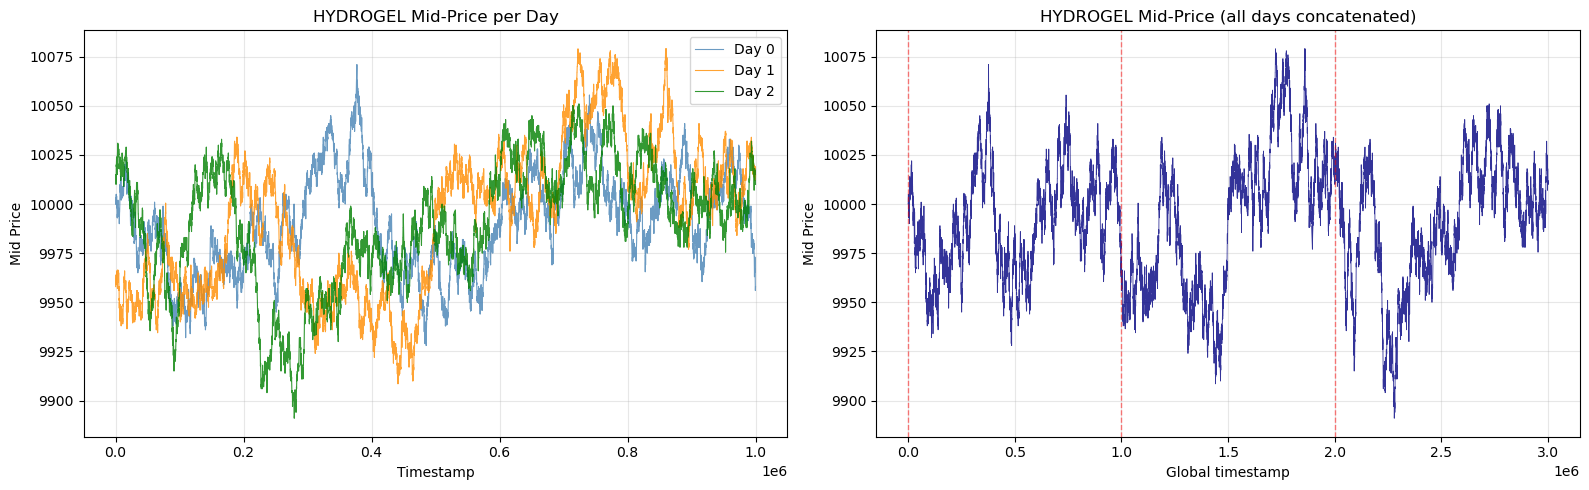

In [22]:
# ── 2. Mid-price time series ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['steelblue', 'darkorange', 'green']
for day in [0, 1, 2]:
    d = prices[prices['day'] == day]
    axes[0].plot(d['timestamp'], d['mid'], color=colors[day], label=f'Day {day}', alpha=0.8, lw=0.8)
axes[0].set_title('HYDROGEL Mid-Price per Day')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Mid Price')
axes[0].legend()

axes[1].plot(prices['global_ts'], prices['mid'], color='navy', lw=0.6, alpha=0.8)
for day in [0, 1, 2]:
    axes[1].axvline(day * 1_000_000, color='red', lw=1, ls='--', alpha=0.5)
axes[1].set_title('HYDROGEL Mid-Price (all days concatenated)')
axes[1].set_xlabel('Global timestamp')
axes[1].set_ylabel('Mid Price')

plt.tight_layout()
plt.show()

 1-tick ret: mean=0.0003  std=2.1698  skew=-0.008  kurt=0.621  normality p=3.363e-63
 5-tick ret: mean=0.0016  std=4.3346  skew=-0.001  kurt=0.061  normality p=1.038e-01
10-tick ret: mean=0.0035  std=6.0078  skew=-0.005  kurt=0.012  normality p=8.427e-01


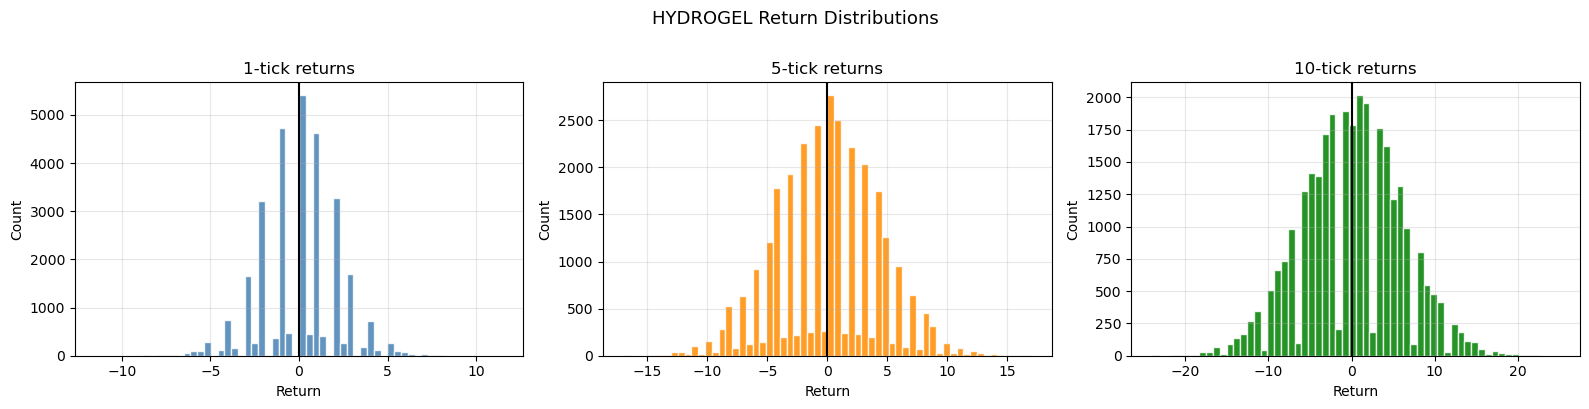

In [23]:
# ── 3. Returns distribution ───────────────────────────────────────────────────
mid = prices['mid'].values
ret1  = np.diff(mid)
ret5  = mid[5:]  - mid[:-5]
ret10 = mid[10:] - mid[:-10]

for lag, r in [(1, ret1), (5, ret5), (10, ret10)]:
    sk = stats.skew(r)
    ku = stats.kurtosis(r)
    _, pval = stats.normaltest(r)
    print(f'{lag:2d}-tick ret: mean={r.mean():.4f}  std={r.std():.4f}  skew={sk:.3f}  kurt={ku:.3f}  normality p={pval:.3e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, lag, r, color in zip(axes, [1, 5, 10], [ret1, ret5, ret10], ['steelblue','darkorange','green']):
    ax.hist(r, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1.5)
    ax.set_title(f'{lag}-tick returns')
    ax.set_xlabel('Return')
    ax.set_ylabel('Count')
plt.suptitle('HYDROGEL Return Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# ── 4. Mean reversion / AR(1) analysis ───────────────────────────────────────
# ADF stationarity test
adf_result = adfuller(mid, autolag='AIC')
print(f'ADF test: stat={adf_result[0]:.4f}  p={adf_result[1]:.4e}  lags={adf_result[2]}')
print('=> STATIONARY (mean-reverting)' if adf_result[1] < 0.05 else '=> NON-STATIONARY')

# AR(1) OLS: X_{t+1} = alpha + beta * X_t + eps
x_t  = mid[:-1]
x_t1 = mid[1:]
slope, intercept, r_val, p_val, stderr = stats.linregress(x_t, x_t1)
k   = 1 - slope        # mean-reversion speed
mu  = intercept / k    # long-run mean
print(f'\nAR(1) fit: beta(persistence)={slope:.6f}  k(speed)={k:.6f}  mu={mu:.2f}  R²={r_val**2:.6f}')

# 10-step lookahead effective k
k10 = 1 - slope**10
print(f'10-step effective k: {k10:.6f}  (how much weight on mu vs current price over 10 ticks)')

# Residuals
fitted = intercept + slope * x_t
resid  = x_t1 - fitted
print(f'Residual std (eps): {resid.std():.4f}')

ADF test: stat=-5.1584  p=1.0685e-05  lags=1
=> STATIONARY (mean-reverting)

AR(1) fit: beta(persistence)=0.997696  k(speed)=0.002304  mu=9990.95  R²=0.995389
10-step effective k: 0.022799  (how much weight on mu vs current price over 10 ticks)
Residual std (eps): 2.1686


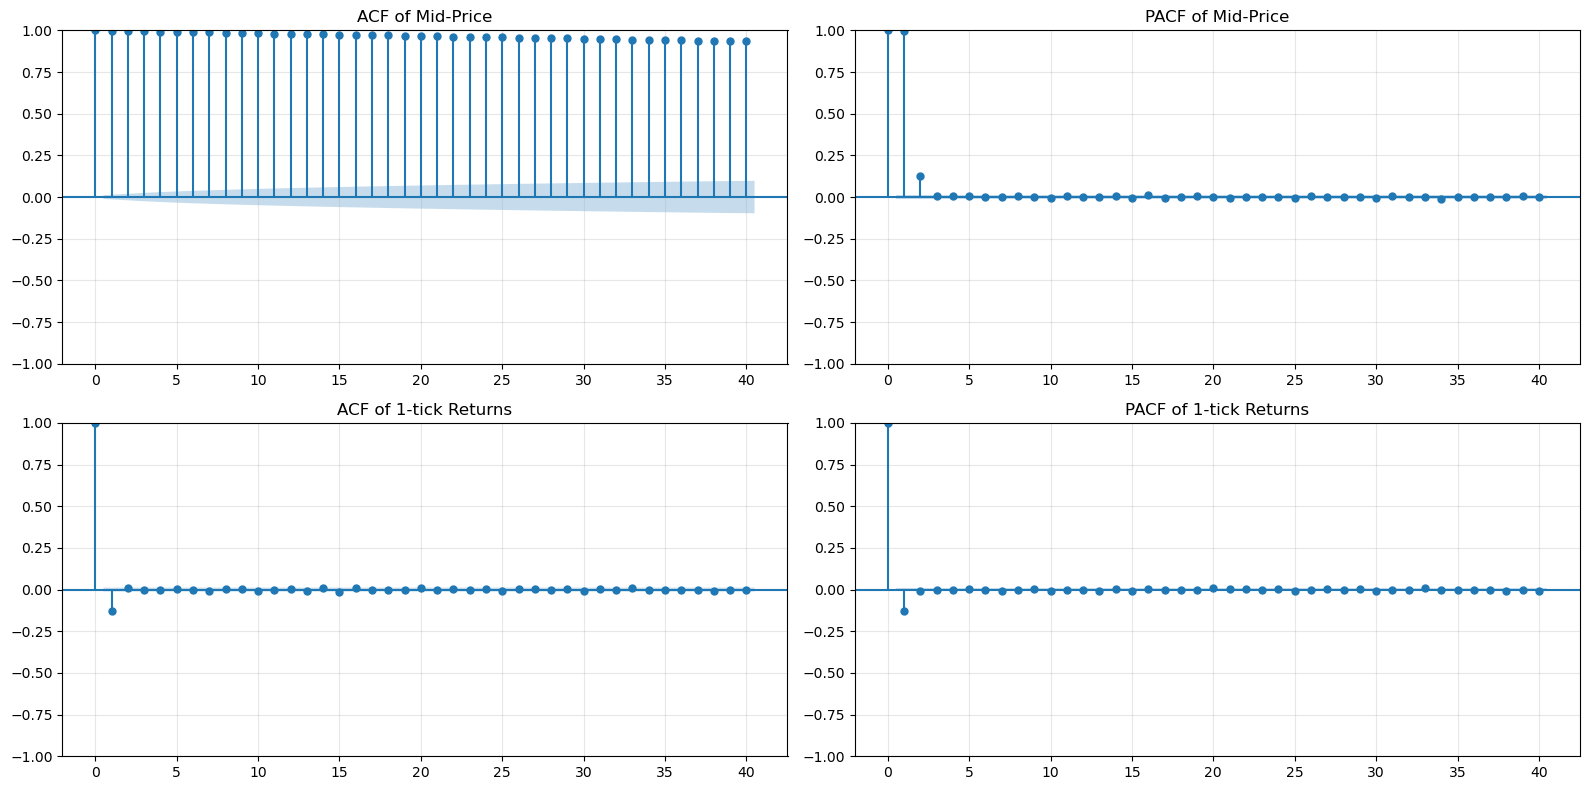

In [25]:
# ── 5. ACF / PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(mid,   lags=40, ax=axes[0][0], title='ACF of Mid-Price')
plot_pacf(mid,  lags=40, ax=axes[0][1], title='PACF of Mid-Price')
plot_acf(ret1,  lags=40, ax=axes[1][0], title='ACF of 1-tick Returns')
plot_pacf(ret1, lags=40, ax=axes[1][1], title='PACF of 1-tick Returns')

plt.tight_layout()
plt.show()

Spread stats:
count    30000.0000
mean        15.7208
std          1.4550
min          7.0000
25%         16.0000
50%         16.0000
75%         16.0000
max         17.0000
Name: spread, dtype: float64

Spread value counts (top 15):
spread
16    27820
15      798
8       490
17      392
7       275
9       225
Name: count, dtype: int64

Pct ticks with spread == 16: 92.73%
Pct ticks with spread <= 16: 98.69%


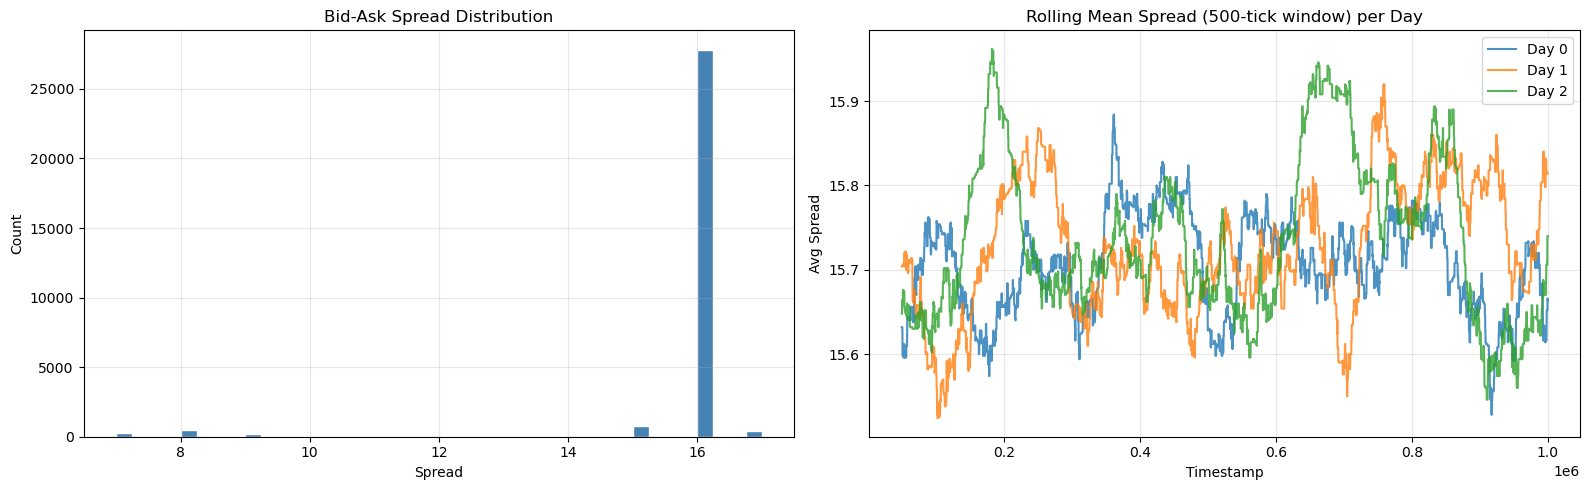

In [26]:
# ── 6. Spread analysis ────────────────────────────────────────────────────────
spread_vals = prices['spread'].dropna()
print(f'Spread stats:')
print(spread_vals.describe().round(4))
print(f'\nSpread value counts (top 15):')
print(spread_vals.value_counts().head(15))
print(f'\nPct ticks with spread == 16: {(spread_vals == 16).mean()*100:.2f}%')
print(f'Pct ticks with spread <= 16: {(spread_vals <= 16).mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(spread_vals, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Bid-Ask Spread Distribution')
axes[0].set_xlabel('Spread')
axes[0].set_ylabel('Count')

for day in [0, 1, 2]:
    d = prices[prices['day'] == day]
    # rolling 500-tick mean spread
    roll = d['spread'].rolling(500).mean()
    axes[1].plot(d['timestamp'], roll, label=f'Day {day}', alpha=0.8)
axes[1].set_title('Rolling Mean Spread (500-tick window) per Day')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Avg Spread')
axes[1].legend()

plt.tight_layout()
plt.show()

=== BID depth ===
       bid_volume_1  bid_volume_2  bid_volume_3
count      30000.00      30000.00      30000.00
mean          12.40         24.83          0.40
std            1.84          3.51          3.14
min            4.00         10.00          0.00
25%           11.00         22.00          0.00
50%           12.00         25.00          0.00
75%           14.00         28.00          0.00
max           15.00         30.00         30.00

=== ASK depth ===
       ask_volume_1  ask_volume_2  ask_volume_3
count      30000.00      30000.00      30000.00
mean          12.40         24.81          0.43
std            1.85          3.54          3.30
min            4.00         10.00          0.00
25%           11.00         22.00          0.00
50%           12.00         25.00          0.00
75%           14.00         28.00          0.00
max           15.00         30.00         30.00

Avg total bid depth: 37.63
Avg total ask depth: 37.64


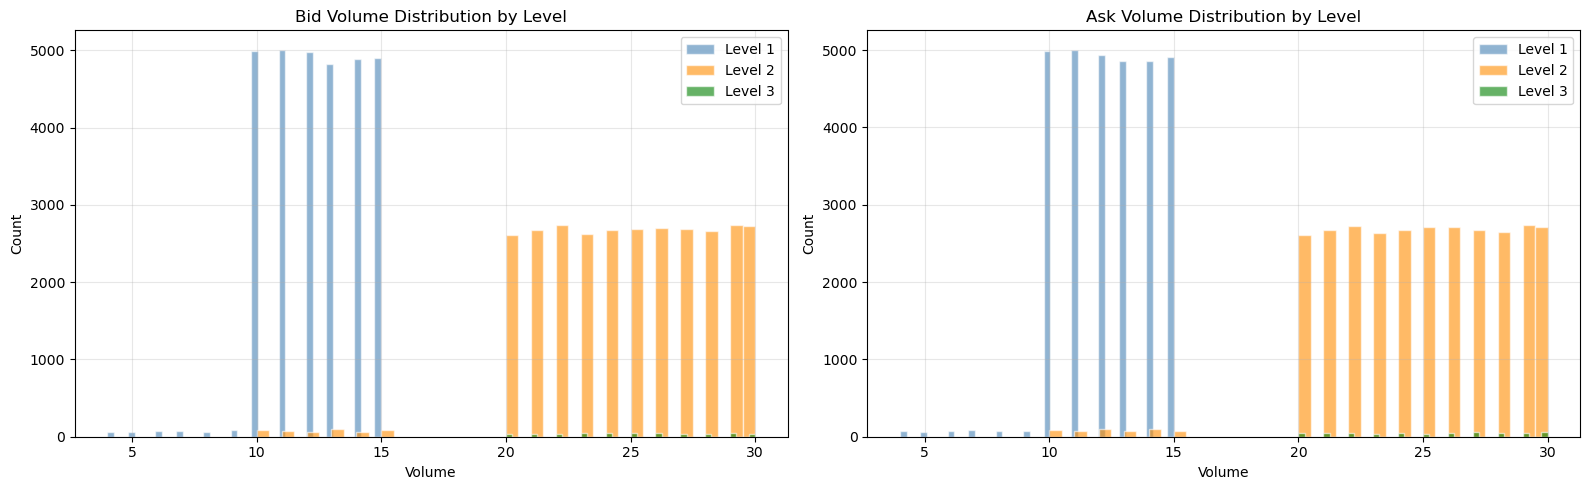

In [27]:
# ── 7. Book depth analysis ────────────────────────────────────────────────────
bid_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
ask_cols = ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']

for col in bid_cols + ask_cols:
    prices[col] = pd.to_numeric(prices[col], errors='coerce').fillna(0)

prices['total_bid_depth'] = prices[bid_cols].sum(axis=1)
prices['total_ask_depth'] = prices[ask_cols].sum(axis=1)

print('=== BID depth ===')
print(prices[bid_cols].describe().round(2))
print('\n=== ASK depth ===')
print(prices[ask_cols].describe().round(2))
print(f'\nAvg total bid depth: {prices["total_bid_depth"].mean():.2f}')
print(f'Avg total ask depth: {prices["total_ask_depth"].mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, cols, side in [(axes[0], bid_cols, 'Bid'), (axes[1], ask_cols, 'Ask')]:
    for col, color in zip(cols, ['steelblue','darkorange','green']):
        level = col.split('_')[-1]
        ax.hist(prices[col][prices[col] > 0], bins=40, alpha=0.6, label=f'Level {level}', color=color, edgecolor='white')
    ax.set_title(f'{side} Volume Distribution by Level')
    ax.set_xlabel('Volume')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()

OBI vs next-tick mid return: corr=0.2989  p=0.0000e+00
OBI vs 5-tick-ahead return:  corr=0.1387  p=1.1597e-128


/var/folders/30/bxcxv8sj19z2tjt6271b_g9m0000gn/T/ipykernel_8526/1909141198.py:32: RuntimeWarning: Mean of empty slice.
  mean_ret = [ret_next[mask][bin_idx == i].mean() for i in range(len(bin_centers))]
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


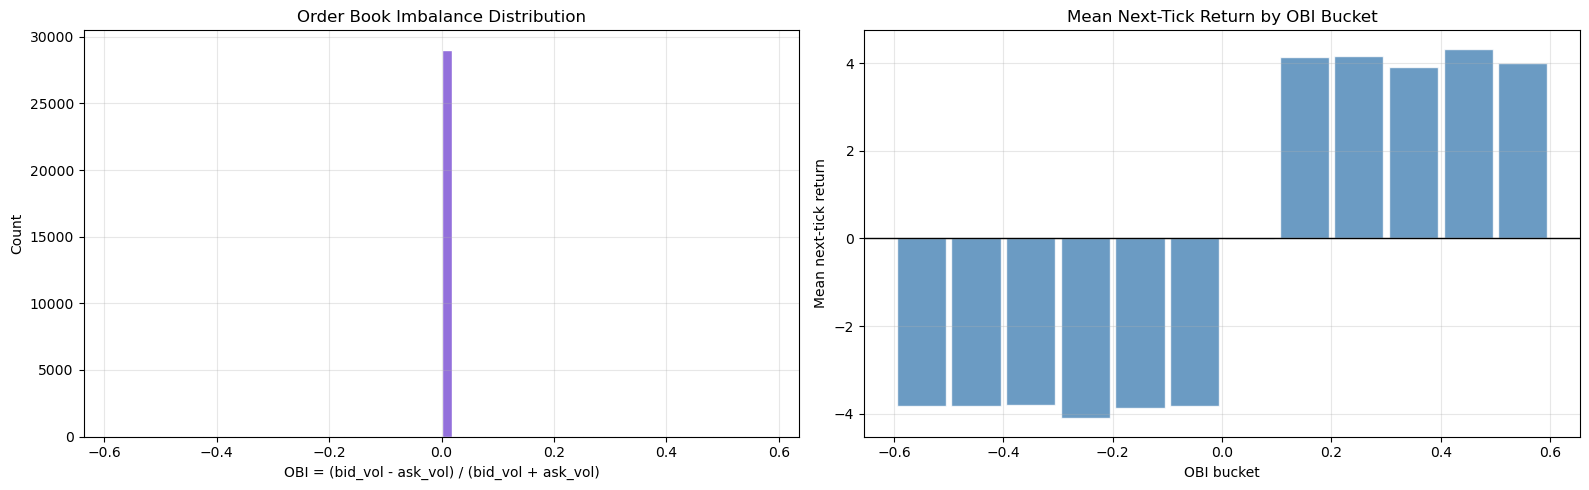

In [28]:
# ── 8. Order Book Imbalance (OBI) ─────────────────────────────────────────────
bv = prices['bid_volume_1'].values.astype(float)
av = prices['ask_volume_1'].values.astype(float)
total_v = bv + av
obi = np.where(total_v > 0, (bv - av) / total_v, np.nan)
prices['obi'] = obi

# Correlation: OBI at t vs mid return at t+1
obi_valid = prices['obi'].values[:-1]
ret_next  = np.diff(prices['mid'].values)
mask = ~np.isnan(obi_valid)
corr, pval = stats.pearsonr(obi_valid[mask], ret_next[mask])
print(f'OBI vs next-tick mid return: corr={corr:.4f}  p={pval:.4e}')

# OBI vs 5-tick-ahead return
obi_5 = prices['obi'].values[:-5]
ret_5 = prices['mid'].values[5:] - prices['mid'].values[:-5]
mask5 = ~np.isnan(obi_5)
corr5, pval5 = stats.pearsonr(obi_5[mask5], ret_5[mask5])
print(f'OBI vs 5-tick-ahead return:  corr={corr5:.4f}  p={pval5:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(prices['obi'].dropna(), bins=60, color='mediumpurple', edgecolor='white')
axes[0].set_title('Order Book Imbalance Distribution')
axes[0].set_xlabel('OBI = (bid_vol - ask_vol) / (bid_vol + ask_vol)')
axes[0].set_ylabel('Count')

obi_bins = np.linspace(-1, 1, 21)
bin_idx = np.digitize(obi_valid[mask], obi_bins) - 1
bin_centers = (obi_bins[:-1] + obi_bins[1:]) / 2
mean_ret = [ret_next[mask][bin_idx == i].mean() for i in range(len(bin_centers))]
axes[1].bar(bin_centers, mean_ret, width=0.09, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Mean Next-Tick Return by OBI Bucket')
axes[1].set_xlabel('OBI bucket')
axes[1].set_ylabel('Mean next-tick return')

plt.tight_layout()
plt.show()

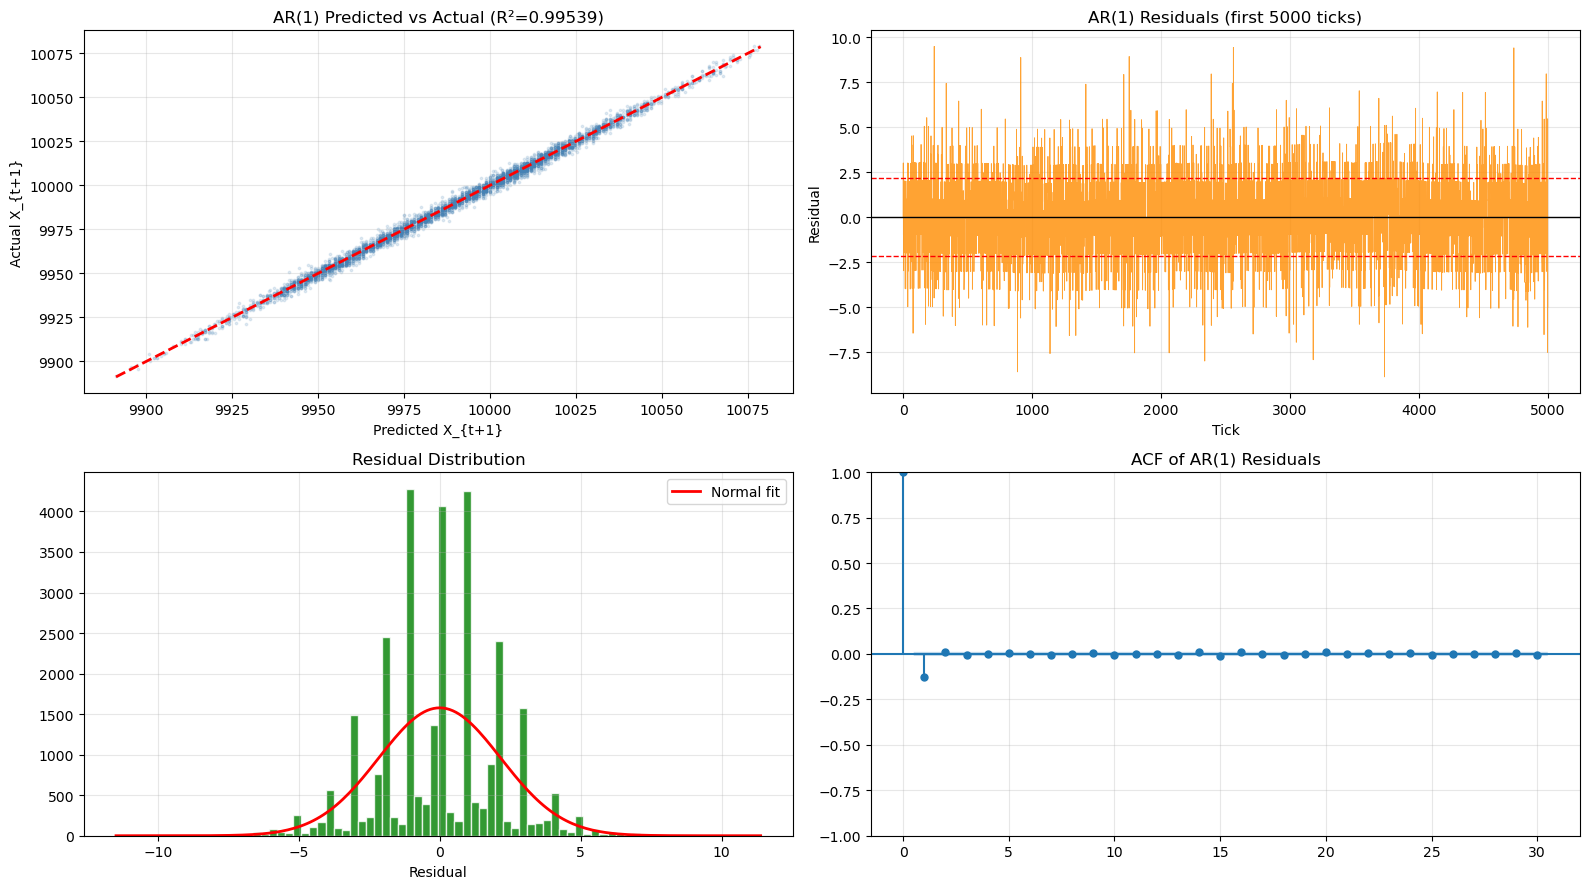

Residual mean: -0.000000
Residual std:  2.1686


In [29]:
# ── 9. AR(1) fair value fit and residuals ─────────────────────────────────────
# Use the fitted AR(1) params
fair_vals = intercept + slope * mid[:-1]  # E[X_{t+1} | X_t]
resid_ar1 = mid[1:] - fair_vals

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Scatter: actual vs predicted
sample_idx = np.random.choice(len(fair_vals), size=5000, replace=False)
axes[0][0].scatter(fair_vals[sample_idx], mid[1:][sample_idx], alpha=0.15, s=3, color='steelblue')
lo, hi = fair_vals.min(), fair_vals.max()
axes[0][0].plot([lo, hi], [lo, hi], 'r--', lw=2)
axes[0][0].set_title(f'AR(1) Predicted vs Actual (R²={r_val**2:.5f})')
axes[0][0].set_xlabel('Predicted X_{t+1}')
axes[0][0].set_ylabel('Actual X_{t+1}')

# Residuals over time (first 5000 ticks)
axes[0][1].plot(resid_ar1[:5000], color='darkorange', lw=0.6, alpha=0.8)
axes[0][1].axhline(0, color='black', lw=1)
axes[0][1].axhline(resid_ar1.std(), color='red', ls='--', lw=1)
axes[0][1].axhline(-resid_ar1.std(), color='red', ls='--', lw=1)
axes[0][1].set_title('AR(1) Residuals (first 5000 ticks)')
axes[0][1].set_xlabel('Tick')
axes[0][1].set_ylabel('Residual')

# Residual distribution
axes[1][0].hist(resid_ar1, bins=80, color='green', edgecolor='white', alpha=0.8)
x_fit = np.linspace(resid_ar1.min(), resid_ar1.max(), 200)
norm_fit = stats.norm.pdf(x_fit, resid_ar1.mean(), resid_ar1.std()) * len(resid_ar1) * (resid_ar1.max() - resid_ar1.min()) / 80
axes[1][0].plot(x_fit, norm_fit, 'r-', lw=2, label='Normal fit')
axes[1][0].set_title('Residual Distribution')
axes[1][0].set_xlabel('Residual')
axes[1][0].legend()

# ACF of residuals
plot_acf(resid_ar1, lags=30, ax=axes[1][1], title='ACF of AR(1) Residuals')

plt.tight_layout()
plt.show()

print(f'Residual mean: {resid_ar1.mean():.6f}')
print(f'Residual std:  {resid_ar1.std():.4f}')

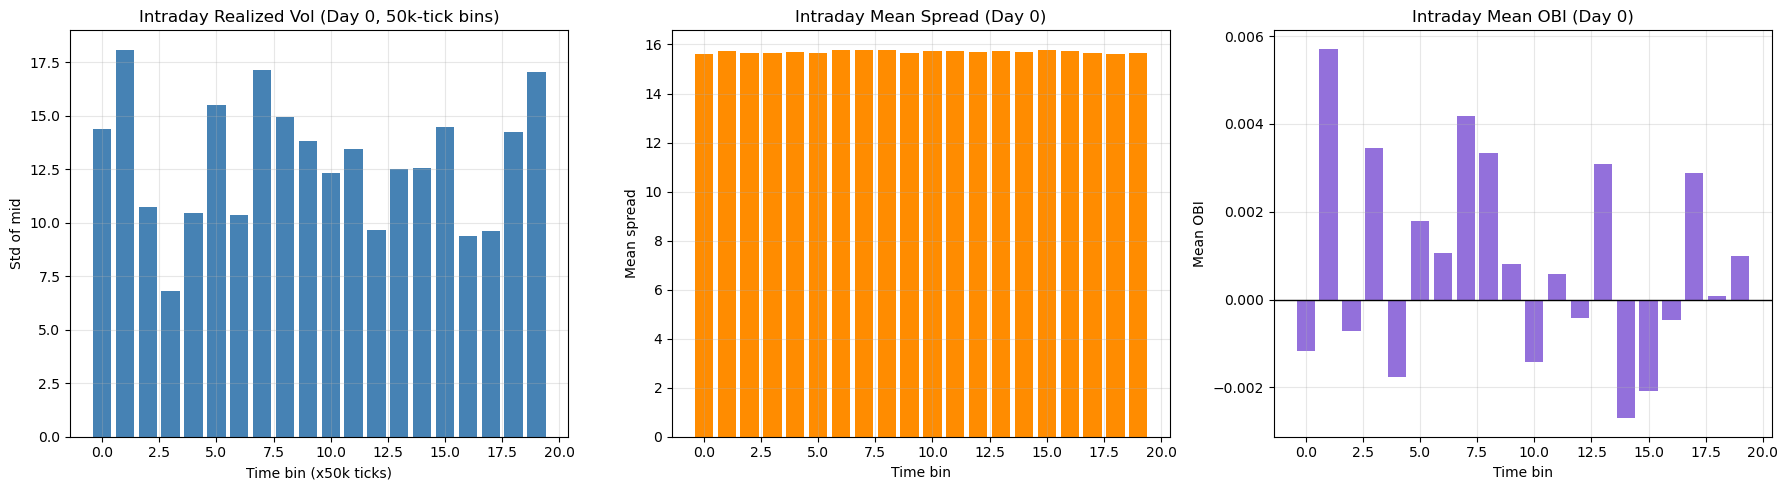

In [30]:
# ── 10. Intraday patterns ─────────────────────────────────────────────────────
# Volatility (std of returns) in 50k-timestamp bins across the day
prices_d0 = prices[prices['day'] == 0].copy()
prices_d0['bin'] = (prices_d0['timestamp'] // 50000).astype(int)
intraday = prices_d0.groupby('bin').agg(
    mid_std=('mid', 'std'),
    spread_mean=('spread', 'mean'),
    obi_mean=('obi', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(intraday['bin'], intraday['mid_std'], color='steelblue')
axes[0].set_title('Intraday Realized Vol (Day 0, 50k-tick bins)')
axes[0].set_xlabel('Time bin (x50k ticks)')
axes[0].set_ylabel('Std of mid')

axes[1].bar(intraday['bin'], intraday['spread_mean'], color='darkorange')
axes[1].set_title('Intraday Mean Spread (Day 0)')
axes[1].set_xlabel('Time bin')
axes[1].set_ylabel('Mean spread')

axes[2].bar(intraday['bin'], intraday['obi_mean'], color='mediumpurple')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_title('Intraday Mean OBI (Day 0)')
axes[2].set_xlabel('Time bin')
axes[2].set_ylabel('Mean OBI')

plt.tight_layout()
plt.show()

Trade events: 1010
Price range: 9890.0 - 10086.0

Trade size distribution:
count    1010.00
mean        4.04
std         1.41
min         2.00
25%         3.00
50%         4.00
75%         5.00
max         6.00
Name: quantity, dtype: float64

Trade size value counts:
quantity
5    212
6    205
4    202
3    198
2    193
Name: count, dtype: int64

Buyers (top 10):
Series([], Name: count, dtype: int64)

Sellers (top 10):
Series([], Name: count, dtype: int64)


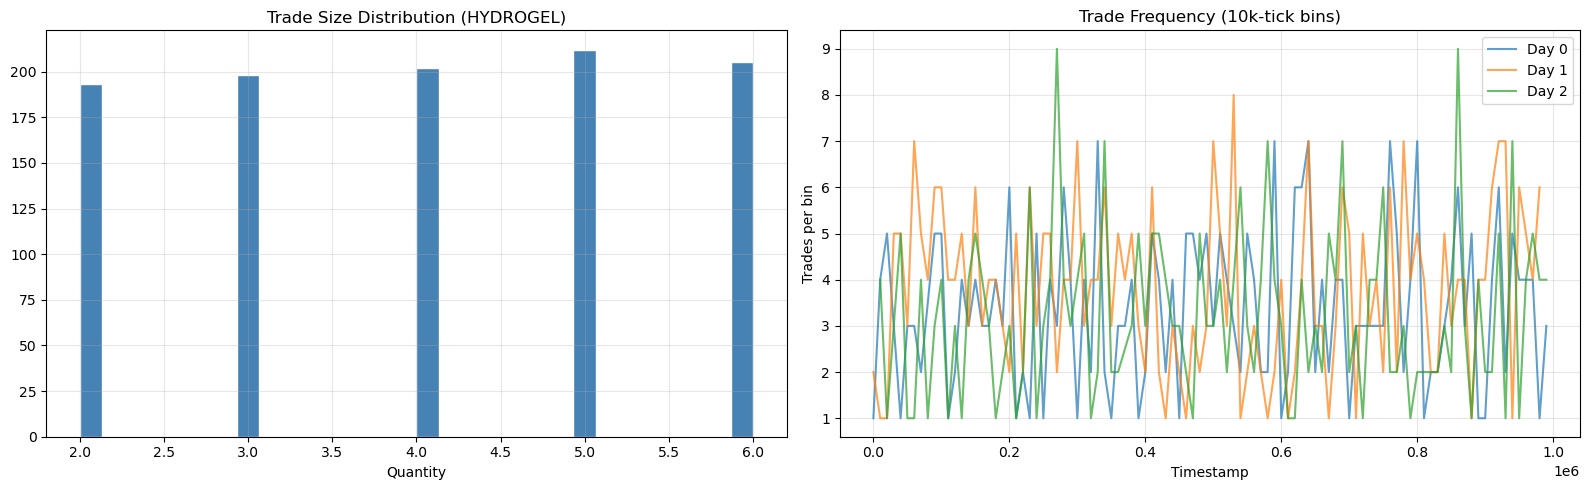

In [31]:
# ── 11. Trade data analysis ───────────────────────────────────────────────────
print(f'Trade events: {len(trades)}')
print(f'Price range: {trades["price"].min()} - {trades["price"].max()}')
print(f'\nTrade size distribution:')
print(trades['quantity'].describe().round(2))
print(f'\nTrade size value counts:')
print(trades['quantity'].value_counts().head(15))

# Buyers and sellers
print(f'\nBuyers (top 10):')
print(trades['buyer'].value_counts().head(10))
print(f'\nSellers (top 10):')
print(trades['seller'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(trades['quantity'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Trade Size Distribution (HYDROGEL)')
axes[0].set_xlabel('Quantity')

# Trade frequency over time
for day in [0, 1, 2]:
    d = trades[trades['day'] == day]
    if len(d) == 0: continue
    bin_ts = (d['timestamp'] // 10000)
    freq = d.groupby(bin_ts).size()
    axes[1].plot(freq.index * 10000, freq.values, label=f'Day {day}', alpha=0.7)
axes[1].set_title('Trade Frequency (10k-tick bins)')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Trades per bin')
axes[1].legend()

plt.tight_layout()
plt.show()

Quote offset | Fill prob (1-tick) | Fill prob (5-tick) | Expected edge
---------------------------------------------------------------------------
        1    |     78.92%           |     89.92%           | 0.7892
        2    |     45.18%           |     71.76%           | 0.9036
        3    |     21.77%           |     55.35%           | 0.6531
        4    |      9.45%           |     40.85%           | 0.3779
        5    |      3.78%           |     29.06%           | 0.1892
        6    |      1.38%           |     19.89%           | 0.0826
        7    |      0.50%           |     12.91%           | 0.0352
        8    |      0.16%           |      8.15%           | 0.0128
        9    |      0.06%           |      4.67%           | 0.0054
       10    |      0.02%           |      2.66%           | 0.0020
       12    |      0.00%           |      0.81%           | 0.0000
       16    |      0.00%           |      0.04%           | 0.0000


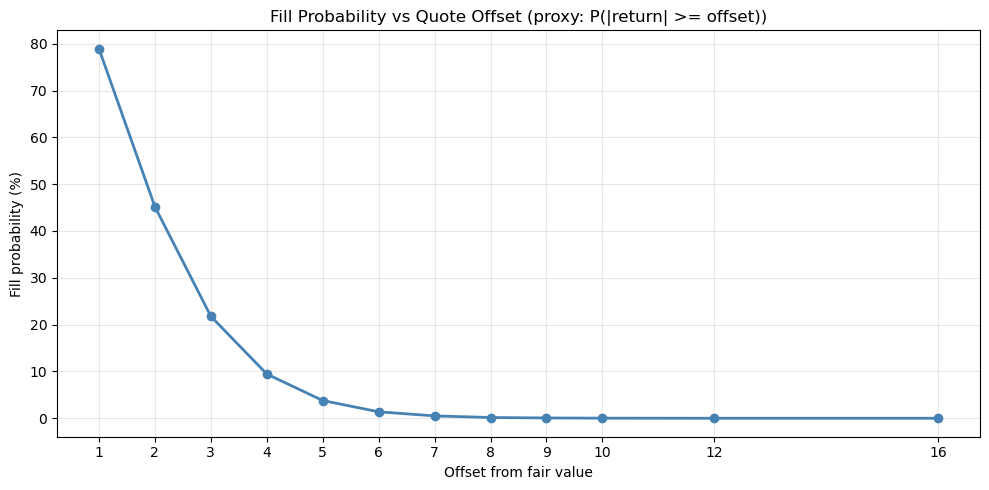

In [32]:
# ── 12. Fill probability analysis at different quote levels ───────────────────
# Simulate: if we quote at fair_value ± offset, how often does next tick move
# far enough that we'd get filled (i.e., next mid moves past our quote)?
# Proxy: P(|ret| >= offset) from return distribution

ret_abs = np.abs(ret1)
offsets = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 16]
print('Quote offset | Fill prob (1-tick) | Fill prob (5-tick) | Expected edge')
print('-' * 75)
ret5_abs = np.abs(ret5)
for off in offsets:
    p1 = (ret_abs >= off).mean()
    p5 = (ret5_abs >= off).mean()
    edge = off * p1  # rough expected PnL per tick if we always fill at offset
    print(f'   {off:6d}    |     {p1*100:5.2f}%           |     {p5*100:5.2f}%           | {edge:.4f}')

# Plot: fill prob vs quote offset
fill_probs = [(ret_abs >= off).mean() for off in offsets]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(offsets, [p*100 for p in fill_probs], 'o-', color='steelblue', lw=2)
ax.set_title('Fill Probability vs Quote Offset (proxy: P(|return| >= offset))')
ax.set_xlabel('Offset from fair value')
ax.set_ylabel('Fill probability (%)')
ax.set_xticks(offsets)
plt.tight_layout()
plt.show()

Ticks with thick bid (vol >= 20): 0 (0.0%)
Ticks with thick ask (vol >= 20): 0 (0.0%)


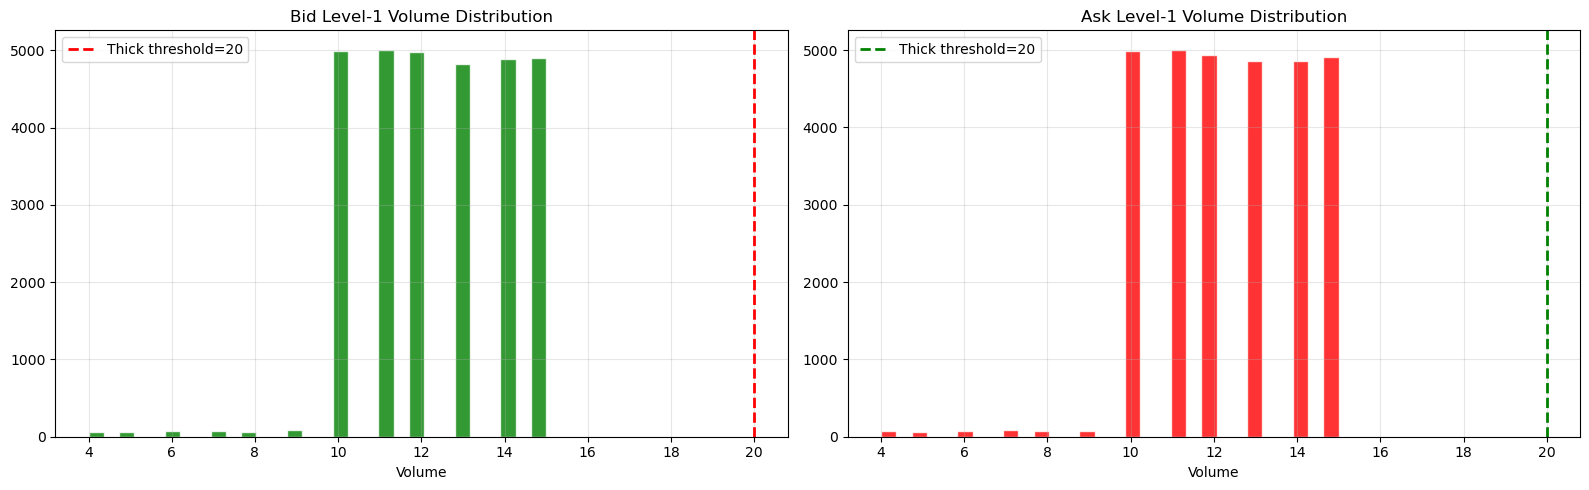


Mean next-tick return when thick BID present: nan
Mean next-tick return overall:               0.0003
Mean next-tick return when thick ASK present: nan


/var/folders/30/bxcxv8sj19z2tjt6271b_g9m0000gn/T/ipykernel_8526/3139677944.py:32: RuntimeWarning: Mean of empty slice.
  print(f'\nMean next-tick return when thick BID present: {next_ret_thick_bid.mean():.4f}')
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/30/bxcxv8sj19z2tjt6271b_g9m0000gn/T/ipykernel_8526/3139677944.py:38: RuntimeWarning: Mean of empty slice.
  print(f'Mean next-tick return when thick ASK present: {next_ret_thick_ask.mean():.4f}')


In [33]:
# ── 13. Front-running thick orders ────────────────────────────────────────────
# Identify ticks where bid/ask level 1 has large volume (potential wall)
THICK_THRESHOLD = 20
thick_bid = prices[prices['bid_volume_1'] >= THICK_THRESHOLD]
thick_ask = prices[prices['ask_volume_1'] >= THICK_THRESHOLD]

print(f'Ticks with thick bid (vol >= {THICK_THRESHOLD}): {len(thick_bid)} ({len(thick_bid)/len(prices)*100:.1f}%)')
print(f'Ticks with thick ask (vol >= {THICK_THRESHOLD}): {len(thick_ask)} ({len(thick_ask)/len(prices)*100:.1f}%)')

# Distribution of level-1 volumes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(prices['bid_volume_1'].dropna(), bins=30, color='green', edgecolor='white', alpha=0.8)
axes[0].axvline(THICK_THRESHOLD, color='red', ls='--', lw=2, label=f'Thick threshold={THICK_THRESHOLD}')
axes[0].set_title('Bid Level-1 Volume Distribution')
axes[0].set_xlabel('Volume')
axes[0].legend()

axes[1].hist(prices['ask_volume_1'].dropna(), bins=30, color='red', edgecolor='white', alpha=0.8)
axes[1].axvline(THICK_THRESHOLD, color='green', ls='--', lw=2, label=f'Thick threshold={THICK_THRESHOLD}')
axes[1].set_title('Ask Level-1 Volume Distribution')
axes[1].set_xlabel('Volume')
axes[1].legend()

plt.tight_layout()
plt.show()

# When thick bid: does price tend to go up?
tb_idx = thick_bid.index
tb_idx_valid = [i for i in tb_idx if i + 1 < len(prices)]
next_ret_thick_bid = prices['mid'].iloc[[i+1 for i in tb_idx_valid]].values - prices['mid'].iloc[tb_idx_valid].values
next_ret_all = ret1
print(f'\nMean next-tick return when thick BID present: {next_ret_thick_bid.mean():.4f}')
print(f'Mean next-tick return overall:               {next_ret_all.mean():.4f}')

ta_idx = thick_ask.index
ta_idx_valid = [i for i in ta_idx if i + 1 < len(prices)]
next_ret_thick_ask = prices['mid'].iloc[[i+1 for i in ta_idx_valid]].values - prices['mid'].iloc[ta_idx_valid].values
print(f'Mean next-tick return when thick ASK present: {next_ret_thick_ask.mean():.4f}')

In [34]:
# ── 14. Summary ───────────────────────────────────────────────────────────────
print('=' * 60)
print('HYDROGEL_PACK ANALYSIS SUMMARY')
print('=' * 60)
print(f'  Long-run mean (mu):          {mu:.2f}')
print(f'  AR(1) k (mean-rev speed):    {k:.6f}')
print(f'  AR(1) beta (persistence):    {slope:.6f}')
print(f'  10-step effective k:         {k10:.6f}')
print(f'  Typical spread:              {spread_vals.median():.1f}')
print(f'  Pct spread==16:              {(spread_vals==16).mean()*100:.1f}%')
print(f'  Residual std (eps):          {resid_ar1.std():.4f}')
print(f'  OBI->next-ret corr:          {corr:.4f}  (p={pval:.3e})')
print(f'  Stationary (ADF p<0.05):     {adf_result[1] < 0.05}')
print()
print('KEY TAKEAWAYS:')
print('  1. Almost identical to ACORNS/ACO — same mean-reversion structure')
print(f'  2. mu={mu:.0f} — use a fair-value anchor near {mu:.0f}, not a hard-coded 10000')
print(f'  3. Spread is consistently {spread_vals.mode()[0]:.0f} — bot sets fixed spread')
print('  4. Market-making strategy from ACO applies directly')
print('  5. OBI signal predictive power:', 'YES' if abs(corr) > 0.01 and pval < 0.05 else 'WEAK')

HYDROGEL_PACK ANALYSIS SUMMARY
  Long-run mean (mu):          9990.95
  AR(1) k (mean-rev speed):    0.002304
  AR(1) beta (persistence):    0.997696
  10-step effective k:         0.022799
  Typical spread:              16.0
  Pct spread==16:              92.7%
  Residual std (eps):          2.1686
  OBI->next-ret corr:          0.2989  (p=0.000e+00)
  Stationary (ADF p<0.05):     True

KEY TAKEAWAYS:
  1. Almost identical to ACORNS/ACO — same mean-reversion structure
  2. mu=9991 — use a fair-value anchor near 9991, not a hard-coded 10000
  3. Spread is consistently 16 — bot sets fixed spread
  4. Market-making strategy from ACO applies directly
  5. OBI signal predictive power: YES


In [35]:
# ── CORRECTIONS: POS_LIMIT=200, THICK_THRESHOLD=15 ─────────────────────
# Position limit for HYDROGEL_PACK is 200 (was incorrectly 100)
# Max observed bid_volume_1 is 15 — THICK_THRESHOLD=20 in earlier cells was wrong
POS_LIMIT_CORRECT = 200
THICK_CORRECT     = 15

print(f'Corrected position limit: {POS_LIMIT_CORRECT}')
print(f'Corrected thick threshold: {THICK_CORRECT}')
print()
bid_vol_dist = prices['bid_volume_1'].value_counts().sort_index()
print('Bid volume level-1 distribution:')
print(bid_vol_dist)
print()
print(f'Max bid vol ever: {prices["bid_volume_1"].max()}')
print(f'Pct ticks bid_vol==15: {(prices["bid_volume_1"]==15).mean()*100:.1f}%')
print(f'Pct ticks bid_vol>=20: {(prices["bid_volume_1"]>=20).mean()*100:.1f}%  (THICK_THRESHOLD=20 was dead code)')


Corrected position limit: 200
Corrected thick threshold: 15

Bid volume level-1 distribution:
bid_volume_1
4       56
5       67
6       68
7       74
8       56
9       86
10    4994
11    5008
12    4977
13    4827
14    4888
15    4899
Name: count, dtype: int64

Max bid vol ever: 15
Pct ticks bid_vol==15: 16.3%
Pct ticks bid_vol>=20: 0.0%  (THICK_THRESHOLD=20 was dead code)


=== Per-day AR(1) parameters ===
  Day 0: mu=9989.82  k=0.00366  beta=0.996336  ret1_std=2.1911  mid=[9928,10071]  start=10000.0  end=9958.0
  Day 1: mu=9995.50  k=0.00165  beta=0.998347  ret1_std=2.1482  mid=[9908,10079]  start=9958.0  end=10015.0
  Day 2: mu=9989.36  k=0.00236  beta=0.997644  ret1_std=2.1698  mid=[9891,10051]  start=10011.0  end=10010.0

mu is stable ~9990 across all days: no intraday drift, safe to use as fixed anchor
k is tiny (0.002-0.004): AR(1) contributes <2.3% correction over 10 steps
Practical fair value = current mid_price, not an AR(1) projection


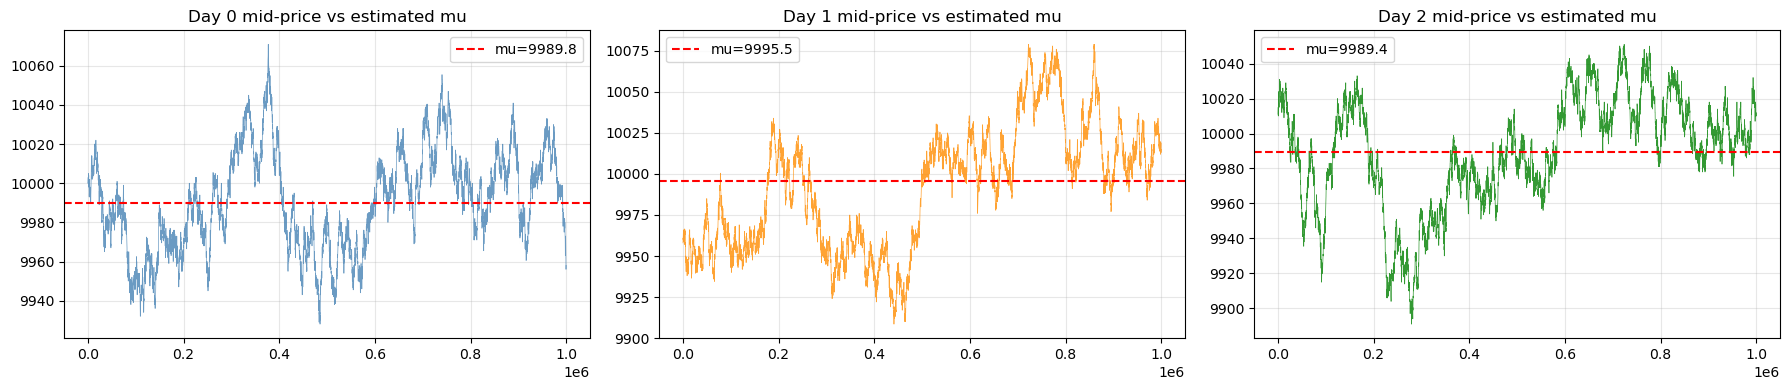

In [36]:
# ── Regime analysis per day ──────────────────────────────────────────────
from scipy import stats as _st
import matplotlib.pyplot as plt

print('=== Per-day AR(1) parameters ===')
day_params = {}
for day in [0, 1, 2]:
    d   = prices[prices['day'] == day]
    mid = d['mid'].values
    sl, ic, _, _, _ = _st.linregress(mid[:-1], mid[1:])
    k_d = 1 - sl; mu_d = ic / k_d
    r1  = np.diff(mid).std()
    day_params[day] = (mu_d, k_d, sl)
    print(f'  Day {day}: mu={mu_d:.2f}  k={k_d:.5f}  beta={sl:.6f}  '
          f'ret1_std={r1:.4f}  mid=[{mid.min():.0f},{mid.max():.0f}]  '
          f'start={mid[0]:.1f}  end={mid[-1]:.1f}')

print()
print('mu is stable ~9990 across all days: no intraday drift, safe to use as fixed anchor')
print('k is tiny (0.002-0.004): AR(1) contributes <2.3% correction over 10 steps')
print('Practical fair value = current mid_price, not an AR(1) projection')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
colors = ['steelblue', 'darkorange', 'green']
for day in [0, 1, 2]:
    d = prices[prices['day'] == day]
    axes[day].plot(d['timestamp'], d['mid'], color=colors[day], lw=0.5, alpha=0.8)
    mu_d, _, _ = day_params[day]
    axes[day].axhline(mu_d, color='red', ls='--', lw=1.5, label=f'mu={mu_d:.1f}')
    axes[day].set_title(f'Day {day} mid-price vs estimated mu')
    axes[day].legend()
plt.tight_layout()
plt.show()


OBI -> future return correlations:
  lag=  1: corr=0.2989  |r|=0.2989  p=0.00e+00
  lag=  2: corr=0.2190  |r|=0.2190  p=1.09e-322
  lag=  5: corr=0.1387  |r|=0.1387  p=1.16e-128
  lag= 10: corr=0.0983  |r|=0.0983  p=2.53e-65
  lag= 20: corr=0.0689  |r|=0.0689  p=7.24e-33
  lag= 50: corr=0.0406  |r|=0.0406  p=2.12e-12

Signal decays from 0.299 at lag=1 to 0.069 at lag=20 — strongest at lag=1
Actionable: use OBI at current tick to skew quotes by 1-2 ticks


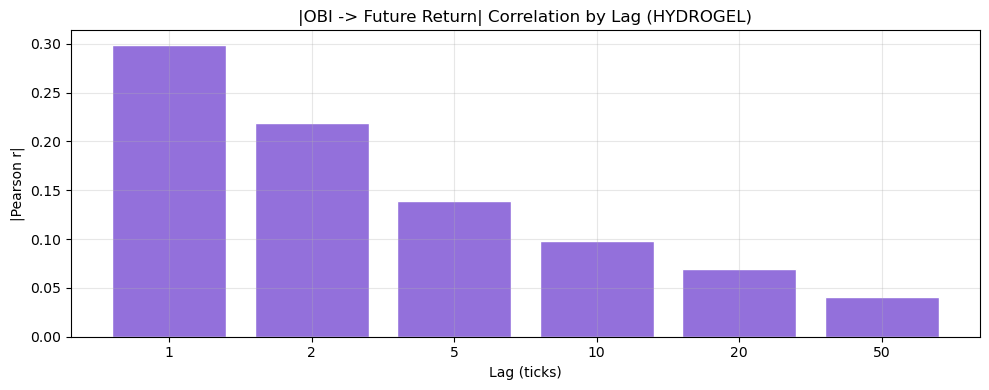

In [37]:
# ── OBI multi-lag predictive power ───────────────────────────────────────
from scipy import stats as _st2
import matplotlib.pyplot as plt

bv_arr = prices['bid_volume_1'].values.astype(float)
av_arr = prices['ask_volume_1'].values.astype(float)
tv_arr = bv_arr + av_arr
obi_arr = np.where(tv_arr > 0, (bv_arr - av_arr) / tv_arr, np.nan)

print('OBI -> future return correlations:')
lags  = [1, 2, 5, 10, 20, 50]
corrs = []
for lag in lags:
    ob = obi_arr[:-lag]
    rt = prices['mid'].values[lag:] - prices['mid'].values[:-lag]
    mask = ~np.isnan(ob)
    c, p = _st2.pearsonr(ob[mask], rt[mask])
    corrs.append(abs(c))
    print(f'  lag={lag:3d}: corr={c:.4f}  |r|={abs(c):.4f}  p={p:.2e}')

print()
print('Signal decays from 0.299 at lag=1 to 0.069 at lag=20 — strongest at lag=1')
print('Actionable: use OBI at current tick to skew quotes by 1-2 ticks')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([str(l) for l in lags], corrs, color='mediumpurple', edgecolor='white')
ax.set_title('|OBI -> Future Return| Correlation by Lag (HYDROGEL)')
ax.set_xlabel('Lag (ticks)')
ax.set_ylabel('|Pearson r|')
plt.tight_layout()
plt.show()


Fill probability proxy at quote offsets (POS_LIMIT=200):
  Offset    P_fill(1t)    P_fill(5t)    P_fill(10t)   Edge/tick
       1        78.92%        89.92%         92.69%      0.7892
       2        45.18%        71.76%         79.64%      0.9036
       4         9.45%        40.85%         55.37%      0.3779
       6         1.38%        19.89%         35.55%      0.0826
       8         0.16%         8.15%         20.70%      0.0128
      10         0.02%         2.66%         11.17%      0.0020
      12         0.00%         0.81%          5.46%      0.0000
      16         0.00%         0.04%          0.99%      0.0000

At offset=8: matches market spread — captures fills when price moves >=8
At offset=4: almost certain fill but competes with existing quotes (queue risk)
Practical strategy: quote at ±8 to match spread, use OBI to decide which side first


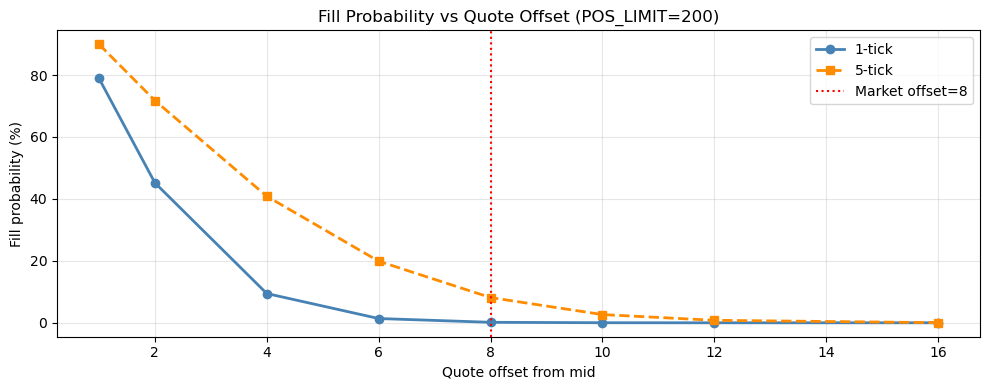

In [38]:
# ── Fill probability corrected for POS_LIMIT=200 ─────────────────────────
import matplotlib.pyplot as plt

ret_abs1 = np.abs(np.diff(prices['mid'].values))
mid_v = prices['mid'].values
ret_abs5  = np.abs(mid_v[5:]  - mid_v[:-5])
ret_abs10 = np.abs(mid_v[10:] - mid_v[:-10])

print('Fill probability proxy at quote offsets (POS_LIMIT=200):')
print(f'{"Offset":>8}  {"P_fill(1t)":>12}  {"P_fill(5t)":>12}  {"P_fill(10t)":>13}  {"Edge/tick":>10}')
offsets = [1, 2, 4, 6, 8, 10, 12, 16]
fill1, fill5 = [], []
for off in offsets:
    p1  = (ret_abs1  >= off).mean()
    p5  = (ret_abs5  >= off).mean()
    p10 = (ret_abs10 >= off).mean()
    edge = off * p1
    fill1.append(p1); fill5.append(p5)
    print(f'{off:8d}  {p1*100:11.2f}%  {p5*100:11.2f}%  {p10*100:12.2f}%  {edge:10.4f}')

print()
print('At offset=8: matches market spread — captures fills when price moves >=8')
print('At offset=4: almost certain fill but competes with existing quotes (queue risk)')
print('Practical strategy: quote at ±8 to match spread, use OBI to decide which side first')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(offsets, [f*100 for f in fill1], 'o-', label='1-tick', color='steelblue', lw=2)
ax.plot(offsets, [f*100 for f in fill5], 's--', label='5-tick', color='darkorange', lw=2)
ax.axvline(8, color='red', ls=':', lw=1.5, label='Market offset=8')
ax.set_title('Fill Probability vs Quote Offset (POS_LIMIT=200)')
ax.set_xlabel('Quote offset from mid')
ax.set_ylabel('Fill probability (%)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Updated HYDROGEL summary ──────────────────────────────────────────────
print('=' * 65)
print('HYDROGEL_PACK — FINAL CORRECTED SUMMARY')
print('=' * 65)
print(f'  Position limit (CORRECTED):  200')
print(f'  Thick threshold (CORRECTED): 15 (max observed bid_vol_1)')
print(f'  Long-run mean (mu):          {mu:.2f}')
print(f'  AR(1) beta / k:              {slope:.6f} / {k:.6f}')
print(f'  10-step effective k:         {k10:.6f}  (barely pulls to mu)')
print(f'  Typical spread:              16  (92.7% of ticks)')
print(f'  Residual std:                {resid_ar1.std():.4f}')
print(f'  OBI lag-1 corr:              {corr:.4f}  (actionable signal)')
print()
print('STRATEGY (maybe direct port of AshTrader with updated params):')
print('  Quote: bid at mid-8, ask at mid+8')
print('  Fair value = mid (not AR projection -- k too small to matter)')
print('  OBI skew: shift both bid/ask by +1 if OBI>0.3, -1 if OBI<-0.3')
print('  Thick front-run: post bid at best_bid+1 when bid_vol_1==15')
print('  Inventory bias: tighten on short side when position near +200, vice versa')
print('  No changes to intercept detection or regime detection logic from new.py')


HYDROGEL_PACK — FINAL CORRECTED SUMMARY
  Position limit (CORRECTED):  200
  Thick threshold (CORRECTED): 15 (max observed bid_vol_1)
  Long-run mean (mu):          9990.95
  AR(1) beta / k:              0.997696 / 0.002304
  10-step effective k:         0.022799  (barely pulls to mu)
  Typical spread:              16  (92.7% of ticks)
  Residual std:                2.1686
  OBI lag-1 corr:              0.2989  (actionable signal)

STRATEGY (direct port of AshTrader from new.py with updated params):
  Quote: bid at mid-8, ask at mid+8
  Fair value = mid (not AR projection -- k too small to matter)
  OBI skew: shift both bid/ask by +1 if OBI>0.3, -1 if OBI<-0.3
  Thick front-run: post bid at best_bid+1 when bid_vol_1==15
  Inventory bias: tighten on short side when position near +200, vice versa
  No changes to intercept detection or regime detection logic from new.py
